# Objective Pupil and First-Order Filtering

Stage C geometry notebook for the `slm_plane -> fourier_filter_plane -> objective_pupil_plane -> surface_plane` route. It separates objective/NA geometry from full propagation so clipping and first-order limits are visible.


## Stage 8.7 Adjustable Quick-Look Guidance

<!-- STAGE87: adjustable quicklook guidance -->

For fast parameter scouting, use `notebooks/quicklook/00_quick_beam_to_sample_simulator.ipynb`. This notebook remains on its locked stage path: existing execution logic, propagation-power labels, material-proxy caveats, and governance routing are unchanged.

Safe local edits are the explicit config variables already exposed by this notebook, or a copied exploratory run. Keep `fail` and `marginal` labels visible. If a displayed image is visually smoothed, treat that as display interpolation only; rerun balanced/publication sampling before numerical interpretation.


In [1]:
from dataclasses import replace
from pathlib import Path

import pandas as pd

import bessel_twin_core as bt
from vbb_study import setup_study, vbb_regime, vbb_studies
from vbb_study.equations import objective_pupil as objp
from vbb_study.publication import lab_realism as lab_schema

PATHS = setup_study.bootstrap(Path.cwd())
PRESET = "fast"
RUN_ID = PATHS.get("run_id") or None
out_csv = PATHS["csv"] / "stage_c"
out_csv.mkdir(parents=True, exist_ok=True)
out_fig = PATHS["figures"] / "stage_c"
out_fig.mkdir(parents=True, exist_ok=True)
base = replace(bt.default_config(PRESET), generation_method="holographic")

def _common(case_id, cfg, plane_label, coordinate_frame, **extra):
    row = {
        "case_id": case_id,
        "objective_NA": float(cfg.objective.NA),
        "objective_f_eff_mm": float(cfg.objective.f_eff_m / bt.mm),
        "pupil_radius_mm": float(cfg.objective.pupil_radius_m / bt.mm),
        **extra,
    }
    lab_schema.annotate_lab_realism_row(
        row,
        generation_method="objective_pupil_limited",
        model_level="hardware_route",
        hardware_status="current_lab_realizable",
        plane_label=plane_label,
        coordinate_frame=coordinate_frame,
        run_id=RUN_ID,
        preset=PRESET,
        path="geometry_only",
    )
    return row

## Editable Notebook Controls

<!-- STAGE88: editable controls -->

This cell exposes the intended user-editable controls for exploratory runs. The locked stage logic below is preserved: changing these controls is for local investigation unless the notebook explicitly wires a value into a regenerated canonical output. Keep QA, caveats, and fail/marginal labels visible. For fast beam-to-sample exploration use the quicklook notebook; for publication-grade outputs use the locked stage runner.


In [2]:
# STAGE88: visible editable controls for exploratory notebook use.
# Edit NOTEBOOK_CONTROLS below and re-run this cell to apply parameter
# overrides to `base` before running any study cell below.
from vbb_study.publication import notebook_controls as nb_controls
from vbb_study.config import um as _um

NOTEBOOK_CONTROLS = nb_controls.make_notebook_controls(
    stage='lab_realism',
    # ── edit these to override the base configuration ───────────────────────
    ell=3,
    target_core_diameter_um=3.0,
    target_bessel_length_um=150.0,
    objective_NA=0.45,
    blaze_period_px=20,
)

# Wire control parameters into `base` so downstream cells use them.
_p = NOTEBOOK_CONTROLS.parameters or {}
if "ell" in _p:
    base = replace(base, target=replace(base.target, ell=int(_p["ell"])))
if "target_core_diameter_um" in _p:
    base = replace(base, target=replace(base.target, target_core_diameter_m=float(_p["target_core_diameter_um"]) * _um))
if "target_bessel_length_um" in _p:
    base = replace(base, target=replace(base.target, target_bessel_length_m=float(_p["target_bessel_length_um"]) * _um))
if "objective_NA" in _p:
    base = replace(base, objective=replace(base.objective, NA=float(_p["objective_NA"])))
if "blaze_period_px" in _p:
    base = replace(base, slm=replace(base.slm, blaze_period_px=int(_p["blaze_period_px"])))

try:
    display(nb_controls.describe_controls(NOTEBOOK_CONTROLS))
except NameError:
    print(nb_controls.describe_controls(NOTEBOOK_CONTROLS).to_string(index=False))


,control,value
0,stage,lab_realism
1,run_mode,balanced
2,save_outputs,False
3,use_canonical_outputs,True
4,allow_publication_export,False
5,notes,Edit for exploration; keep QA labels/caveats v...
6,ell,3
7,target_core_diameter_um,3.0
8,target_bessel_length_um,150.0
9,objective_NA,0.45


In [3]:
# Interactive quicklook — adjust sliders and click "Update plots".
# Runs a fast preview only; nothing is saved.
from vbb_study.publication import notebook_widgets as nbw

_panel = nbw.interactive_quicklook(base, method='holographic', preset='fast')
display(_panel)


In [4]:
rows = []
for regime in ("general", "limits"):
    cfg = vbb_regime.config_for_regime(base, regime)
    design = bt.compute_design_from_targets(cfg.laser, cfg.target, cfg.material)
    pupil_radius = objp.pupil_radius_m(cfg.objective.f_eff_m, cfg.objective.NA, cfg.objective.immersion_n)
    fill = objp.gaussian_pupil_fill_fraction(cfg.laser.beam_radius_on_slm_m, pupil_radius)
    rows.append(_common(
        f"{regime}_objective_pupil",
        cfg,
        "objective_pupil_plane",
        "objective_pupil_plane_mm",
        regime=regime,
        pupil_radius_formula="f_eff_m * NA / immersion_n",
        pupil_fill_fraction=fill,
        pupil_clipped_fraction=1.0 - fill,
        pupil_fill_ratio=objp.pupil_fill_ratio(cfg.laser.beam_radius_on_slm_m, pupil_radius),
        fourier_ring_radius_mm=objp.fourier_plane_ring_radius_m(design.kr_slm_m_inv, cfg.objective.f_eff_m, cfg.laser.wavelength_m) / bt.mm,
    ))
objective_pupil_geometry = lab_schema.ordered_lab_realism_frame(rows)
objective_pupil_geometry.to_csv(out_csv / "objective_pupil_geometry_summary.csv", index=False)
objective_pupil_geometry


,run_id,generated_at_utc,source_schema_version,case_id,preset,path,generation_method,model_level,hardware_status,plane_label,...,objective_NA,objective_f_eff_mm,pupil_radius_mm,pupil_clipped_fraction,qa_status,regime,pupil_radius_formula,pupil_fill_fraction,pupil_fill_ratio,fourier_ring_radius_mm
0,20260715T180025Z,2026-07-15T18:00:25.001529+00:00,1.0.0,general_objective_pupil,fast,geometry_only,objective_pupil_limited,hardware_route,current_lab_realizable,objective_pupil_plane,...,0.45,4.0,1.8,0.197899,exploratory,general,f_eff_m * NA / immersion_n,0.802101,1.111111,0.008477
1,20260715T180025Z,2026-07-15T18:00:25.001623+00:00,1.0.0,limits_objective_pupil,fast,geometry_only,objective_pupil_limited,hardware_route,current_lab_realizable,objective_pupil_plane,...,0.45,4.0,1.8,0.197899,exploratory,limits,f_eff_m * NA / immersion_n,0.802101,1.111111,0.038147


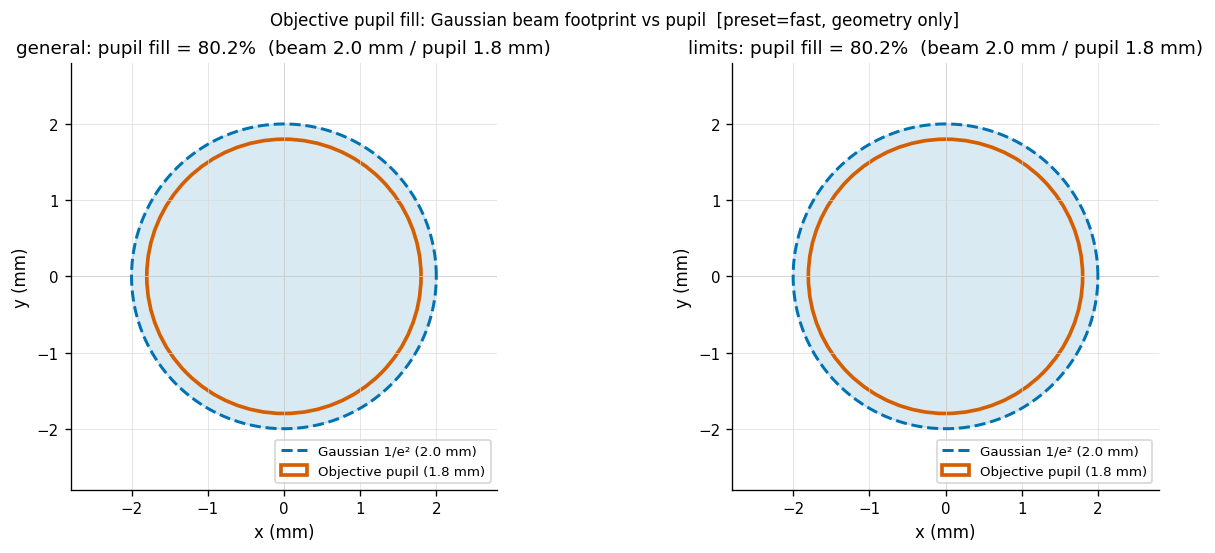

In [5]:
# Pupil-fill schematic: Gaussian beam 1/e² footprint over objective pupil, per regime.
# Task G: preset=fast, geometry only (no propagation).
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

theta = np.linspace(0.0, 2.0 * np.pi, 360)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for i, regime in enumerate(("general", "limits")):
    cfg = vbb_regime.config_for_regime(base, regime)
    pupil_r_mm = float(cfg.objective.pupil_radius_m) * 1e3
    beam_r_mm = float(cfg.laser.beam_radius_on_slm_m) * 1e3
    fill = objp.gaussian_pupil_fill_fraction(cfg.laser.beam_radius_on_slm_m, cfg.objective.pupil_radius_m)
    ax = axes[i]
    # Filled Gaussian beam footprint at 1/e² and 2σ
    ax.fill(beam_r_mm * np.cos(theta), beam_r_mm * np.sin(theta),
            alpha=0.15, color="#0072B2")
    ax.plot(beam_r_mm * np.cos(theta), beam_r_mm * np.sin(theta),
            color="#0072B2", lw=1.8, ls="--",
            label=f"Gaussian 1/e² ({beam_r_mm:.1f} mm)")
    # Objective pupil circle
    ax.add_patch(mpatches.Circle(
        (0, 0), pupil_r_mm, fill=False,
        edgecolor="#D55E00", lw=2.2,
        label=f"Objective pupil ({pupil_r_mm:.1f} mm)",
    ))
    ax.set_aspect("equal")
    lim = max(pupil_r_mm, beam_r_mm) * 1.4
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"{regime}: pupil fill = {fill:.1%}  (beam {beam_r_mm:.1f} mm / pupil {pupil_r_mm:.1f} mm)")
    ax.legend(fontsize=8, loc="lower right")
    ax.axhline(0, color="0.75", lw=0.5, zorder=0)
    ax.axvline(0, color="0.75", lw=0.5, zorder=0)
fig.suptitle(
    f"Objective pupil fill: Gaussian beam footprint vs pupil  [preset={PRESET}, geometry only]",
    fontsize=10,
)
fig.savefig(out_fig / "nb04_pupil_fill_schematic.png", dpi=150, bbox_inches="tight")
plt.show()

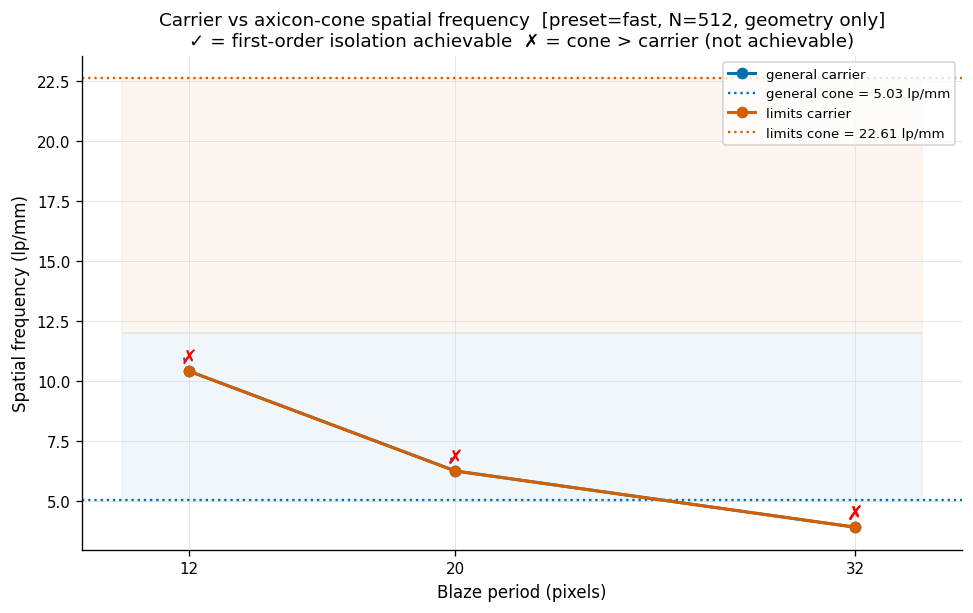

In [6]:
# Carrier-vs-cone diagram: blaze period sweep showing achievable first-order region.
# Achievable = carrier frequency > axicon cone ring frequency.
# Task G: preset=fast, geometry only.
import numpy as np
import matplotlib.pyplot as plt

blaze_pxs = (12, 20, 32)
colors_regime = {"general": "#0072B2", "limits": "#D55E00"}
regime_carriers = {}
regime_cones = {}

for regime in ("general", "limits"):
    cfg = vbb_regime.config_for_regime(base, regime)
    air_cfg = vbb_studies.beam_air_config(cfg)
    design = bt.compute_design_from_targets(air_cfg.laser, air_cfg.target, air_cfg.material)
    grid = bt.make_xy_grid(
        int(air_cfg.grid.N),
        float(air_cfg.slm.pixel_pitch_m) * float(air_cfg.grid.device_downsample),
    )
    cone_lpmm = None
    carriers = []
    for blaze_px in blaze_pxs:
        test_cfg = replace(air_cfg, slm=replace(air_cfg.slm, blaze_period_px=blaze_px))
        geom = bt.first_order_filter_geometry(grid, test_cfg.slm, design)
        carriers.append(float(geom["carrier_lpmm"]))
        if cone_lpmm is None:
            cone_lpmm = float(geom["axicon_cone_radius_lpmm"])
    regime_carriers[regime] = carriers
    regime_cones[regime] = cone_lpmm

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
for regime in ("general", "limits"):
    col = colors_regime[regime]
    carriers = regime_carriers[regime]
    cone = regime_cones[regime]
    ax.plot(list(blaze_pxs), carriers, "o-", color=col, lw=1.8, label=f"{regime} carrier")
    ax.axhline(cone, color=col, ls=":", lw=1.4, label=f"{regime} cone = {cone:.2f} lp/mm")
    for blaze_px, carrier in zip(blaze_pxs, carriers):
        marker = "✓" if carrier > cone else "✗"
        marker_col = col if carrier > cone else "red"
        ax.annotate(
            marker, (blaze_px, carrier),
            textcoords="offset points", xytext=(0, 5),
            ha="center", fontsize=12, color=marker_col,
        )
    # Shade achievable zone (carrier > cone) for this regime
    cone_line = np.full(2, cone)
    ax.fill_between(
        [blaze_pxs[0] - 2, blaze_pxs[-1] + 2], cone_line, [max(regime_carriers[r][0] for r in ("general", "limits")) * 1.15] * 2,
        alpha=0.06, color=col,
    )

ax.set_xlabel("Blaze period (pixels)")
ax.set_ylabel("Spatial frequency (lp/mm)")
ax.set_title(
    f"Carrier vs axicon-cone spatial frequency  [preset={PRESET}, N={base.grid.N}, geometry only]\n"
    "✓ = first-order isolation achievable  ✗ = cone > carrier (not achievable)"
)
ax.set_xticks(list(blaze_pxs))
ax.legend(fontsize=8, loc="upper right")
fig.savefig(out_fig / "nb04_carrier_cone_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
rows = []
for regime in ("general", "limits"):
    cfg = vbb_regime.config_for_regime(base, regime)
    air_cfg = vbb_studies.beam_air_config(cfg)
    design = bt.compute_design_from_targets(air_cfg.laser, air_cfg.target, air_cfg.material)
    grid = bt.make_xy_grid(int(air_cfg.grid.N), float(air_cfg.slm.pixel_pitch_m) * float(air_cfg.grid.device_downsample))
    for blaze_px in (12, 20, 32):
        test_cfg = replace(air_cfg, slm=replace(air_cfg.slm, blaze_period_px=blaze_px))
        geom = bt.first_order_filter_geometry(grid, test_cfg.slm, design)
        status = "current_lab_realizable" if geom["first_order_geometry_valid"] else "diagnostic_only"
        row = _common(
            f"{regime}_blaze{blaze_px}",
            test_cfg,
            "fourier_filter_plane",
            "fourier_filter_plane_spatial_frequency_lpmm",
            regime=regime,
            blaze_period_px=blaze_px,
            **geom,
        )
        row["hardware_status"] = status
        rows.append(row)
first_order_filter_geometry = lab_schema.ordered_lab_realism_frame(rows)
first_order_filter_geometry.to_csv(out_csv / "first_order_filter_geometry_summary.csv", index=False)
first_order_filter_geometry


,run_id,generated_at_utc,source_schema_version,case_id,preset,path,generation_method,model_level,hardware_status,plane_label,...,regime,blaze_period_px,configured_filter_radius_lpmm,recommended_filter_radius_lpmm,effective_filter_radius_lpmm,carrier_lpmm,axicon_cone_radius_lpmm,frequency_bin_lpmm,first_order_geometry_valid,first_order_geometry_margin_lpmm
0,20260715T180025Z,2026-07-15T18:00:25.848916+00:00,1.0.0,general_blaze12,fast,geometry_only,objective_pupil_limited,hardware_route,current_lab_realizable,fourier_filter_plane,...,general,12,2.5,5.147400,5.147400,10.416667,5.025330,0.061035,True,5.269267
1,20260715T180025Z,2026-07-15T18:00:25.848963+00:00,1.0.0,general_blaze20,fast,geometry_only,objective_pupil_limited,hardware_route,current_lab_realizable,fourier_filter_plane,...,general,20,2.5,5.147400,5.147400,6.250000,5.025330,0.061035,True,1.102600
2,20260715T180025Z,2026-07-15T18:00:25.848992+00:00,1.0.0,general_blaze32,fast,geometry_only,objective_pupil_limited,hardware_route,diagnostic_only,fourier_filter_plane,...,general,32,2.5,5.147400,3.710938,3.906250,5.025330,0.061035,False,-1.241150
3,20260715T180025Z,2026-07-15T18:00:25.855741+00:00,1.0.0,limits_blaze12,fast,geometry_only,objective_pupil_limited,hardware_route,diagnostic_only,fourier_filter_plane,...,limits,12,2.5,22.736053,9.895833,10.416667,22.613983,0.061035,False,-12.319386
4,20260715T180025Z,2026-07-15T18:00:25.855787+00:00,1.0.0,limits_blaze20,fast,geometry_only,objective_pupil_limited,hardware_route,diagnostic_only,fourier_filter_plane,...,limits,20,2.5,22.736053,5.937500,6.250000,22.613983,0.061035,False,-16.486053
5,20260715T180025Z,2026-07-15T18:00:25.855813+00:00,1.0.0,limits_blaze32,fast,geometry_only,objective_pupil_limited,hardware_route,diagnostic_only,fourier_filter_plane,...,limits,32,2.5,22.736053,3.710938,3.906250,22.613983,0.061035,False,-18.829803


In [8]:
rows = []
for beam_radius_mm in (1.0, 2.0, 3.0):
    cfg = replace(base, laser=replace(base.laser, beam_radius_on_slm_m=beam_radius_mm * bt.mm))
    pupil_radius = cfg.objective.pupil_radius_m
    fill = objp.gaussian_pupil_fill_fraction(cfg.laser.beam_radius_on_slm_m, pupil_radius)
    rows.append(_common(
        f"beam_radius_{beam_radius_mm:g}mm",
        cfg,
        "objective_pupil_plane",
        "objective_pupil_plane_mm",
        beam_radius_on_slm_mm=beam_radius_mm,
        pupil_fill_fraction=fill,
        pupil_clipped_fraction=1.0 - fill,
        pupil_fill_ratio=objp.pupil_fill_ratio(cfg.laser.beam_radius_on_slm_m, pupil_radius),
    ))
pupil_clipping_summary = lab_schema.ordered_lab_realism_frame(rows)
pupil_clipping_summary.to_csv(out_csv / "pupil_clipping_summary.csv", index=False)
pupil_clipping_summary


,run_id,generated_at_utc,source_schema_version,case_id,preset,path,generation_method,model_level,hardware_status,plane_label,coordinate_frame,objective_NA,objective_f_eff_mm,pupil_radius_mm,pupil_clipped_fraction,qa_status,beam_radius_on_slm_mm,pupil_fill_fraction,pupil_fill_ratio
0,20260715T180025Z,2026-07-15T18:00:25.876709+00:00,1.0.0,beam_radius_1mm,fast,geometry_only,objective_pupil_limited,hardware_route,current_lab_realizable,objective_pupil_plane,objective_pupil_plane_mm,0.45,4.0,1.8,0.001534,exploratory,1.0,0.998466,0.555556
1,20260715T180025Z,2026-07-15T18:00:25.876743+00:00,1.0.0,beam_radius_2mm,fast,geometry_only,objective_pupil_limited,hardware_route,current_lab_realizable,objective_pupil_plane,objective_pupil_plane_mm,0.45,4.0,1.8,0.197899,exploratory,2.0,0.802101,1.111111
2,20260715T180025Z,2026-07-15T18:00:25.876765+00:00,1.0.0,beam_radius_3mm,fast,geometry_only,objective_pupil_limited,hardware_route,current_lab_realizable,objective_pupil_plane,objective_pupil_plane_mm,0.45,4.0,1.8,0.486752,exploratory,3.0,0.513248,1.666667
